# Spectral fitting example (AGN)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.ori)       
- binned data (NGC4151_ec200_bkg_binned_data.hdf5, NGC4151_ec200_binned_data.hdf5, & bkg_binned_data.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip)     

**The binned data are simulations of the NGC4151_ec200 Nebula and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a NGC4151_ec200 simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$

where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [3]:
from cosipy import COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter, Line

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

from pathlib import Path

import os

%matplotlib inline

15:47:01 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=319776;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=165301;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=40078;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=372461;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=221296;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=519459;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

15:47:02 INFO      Starting 3ML!                                                                     ]8;id=594794;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=596467;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=764849;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=49688;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=504206;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=71802;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

15:47:03 WARNING   No fermitools installed                                              ]8;id=368974;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=710482;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

15:47:03 WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=216473;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=416670;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=360501;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=367761;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=847713;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=524701;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [4]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

Read in the spacecraft orientation file

In [5]:
# sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC2_Files/20280301_3_month_with_orbital_info.ori") #DC?2
sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori") #DC3

In [7]:
# dr = str(data_path / "DC2_Files/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5") # DC2
dr = str(data_path / "DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5") # DC3

# COSI Analysis

Load binned .hdf5 files

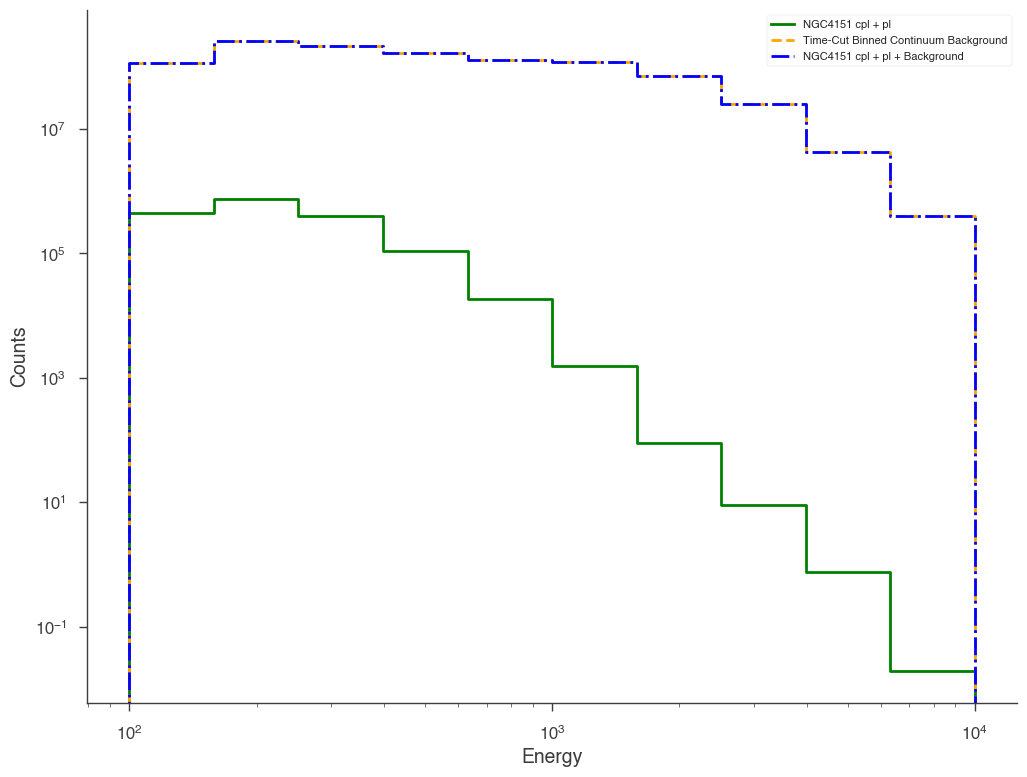

In [ ]:
multiplier = 1

NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec200_DC3_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec200.project("Em").draw(ax, label="NGC4151 cpl + pl", color="green")
bkg.project("Em").draw(ax, label="Time-Cut Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 cpl + pl + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [74]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

### Powerlaw with energy cutoff fit

In [75]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-4
spectrum_cpl.K.max_value = 1
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl.index.max_value = 1

spectrum_cpl.K.delta = 0.05
spectrum_cpl.xc.delta = 10
spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

# model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
# cosi.set_model(model)

In [76]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 100 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
index = -3.0

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 1000
spectrum.index.min_value = -5
spectrum.index.max_value = 5

spectrum.K.delta = 5
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# model = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model = Model(source1, source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [72]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
alpha = -1.0
beta = -3.0
xb = 500. * u.keV
piv = 1. * u.keV

spectrum = Broken_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.alpha.value = alpha
spectrum.beta.value = beta
spectrum.xb.value = xb.value
# spectrum.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-4
spectrum_cpl.K.max_value = 1
spectrum.alpha.min_value = -5
spectrum.alpha.max_value = 5
spectrum.beta.min_value = -5
spectrum.beta.max_value = 5
spectrum.xb.min_value = 100
spectrum.xb.max_value = 10000

spectrum.K.delta = 5
spectrum.alpha.delta = 0.25
spectrum.beta.delta = 0.25
spectrum.xb.delta = 10

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xb.unit = xb.unit

source3 = PointSource("source3",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# model = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model = Model(source3)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

KeyboardInterrupt: 

In [77]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

ratio = 956.53
link_function = Line(a=0.0, b=ratio)   # source1.K = a + b * source2.K
link_function.a.fix = True
link_function.b.fix = True             # keep ratio fixed at 958.4

model.link(
    model.source2.spectrum.main.Powerlaw.K,         # independent
    model.source1.spectrum.main.Cutoff_powerlaw.K,  # dependent
    link_function,
)

like = JointLikelihood(model, plugins, verbose = False)

# like.fit() #increase number of samples?
result = like.fit()

13:56:33 INFO      set the minimizer to minuit                                             ]8;id=34091;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=289226;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(9.999997 +/- 0.000007) x 10^-1,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,-1.8517 +/- 0.0011,
source1.spectrum.main.Cutoff_powerlaw.xc,(1.0000 +/- 0.0004) x 10^2,keV
source2.spectrum.main.Powerlaw.index,-3.03129 +/- 0.00008,
background_cosi,(9.999233 +/- 0.000011) x 10^-1,


Correlation matrix:

1.00,-0.28,0.28,-0.01,-0.01
-0.28,1.00,-1.00,0.03,0.02
0.28,-1.00,1.00,-0.03,-0.02
-0.01,0.03,-0.03,1.00,-0.00
-0.01,0.02,-0.02,-0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.924530e+09
total,-8.924530e+09


Values of statistical measures:

,statistical measures
AIC,-1.784906e+10
BIC,-1.784906e+10


In [ ]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

# like.fit() #increase number of samples?
result = like.fit()

In [131]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

def fit_with_flux_constraint(model, like, max_iterations=20, tolerance=1e-3):
    """
    Fit with constraint that source2 has 10% of source1's flux at 1000 keV
    """
    E = 1000.0  # keV
    
    for i in range(max_iterations):
        s1 = model.source1.spectrum.main.Cutoff_powerlaw
        s2 = model.source2.spectrum.main.Powerlaw
        
        # Target: flux_s2(E) = 0.1 * flux_s1(E)
        # Since flux is proportional to K: K_s2_new / K_s2_current = (flux_target / flux_current)
        flux_s2_current = s2.evaluate_at(E)
        flux_s2_target = 0.1 * s1.evaluate_at(E)
        
        K_s2_new = s2.K.value * (flux_s2_target / flux_s2_current)
        
        # Check convergence
        if i > 0:
            delta_K = abs(K_s2_new - s2.K.value) / s2.K.value
            if delta_K < tolerance:
                print(f"Converged after {i} iterations")
                break
        
        # Fix source2.K to constrained value
        s2.K.value = K_s2_new
        s2.K.fix = True
        
        print(f"Iteration {i+1}: source2.K = {K_s2_new:.3e}")
        
        # Fit with source2.K fixed
        result = like.fit()
    
    # Verify constraint
    ratio = s2.evaluate_at(E) / s1.evaluate_at(E)
    print(f"\nSource 1 flux {E} keV: {s1.evaluate_at(E):.10f}")
    print(f"\nSource 2 flux {E} keV: {s2.evaluate_at(E):.10f}")
    print(f"\nFinal flux ratio at {E} keV: {ratio:.3f}")
    
    return result

# Use it
result = fit_with_flux_constraint(model, like)

13:17:41 INFO      set the minimizer to minuit                                             ]8;id=29266;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=992483;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Iteration 1: source2.K = 2.553e-03


Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(4.5 -0.6 +0.7) x 10^-1,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(1.89 -0.27 +0.31) x 10^2,keV
source2.spectrum.main.Powerlaw.index,-1.8 +/- 0.6,
background_cosi,(10.0000 +/- 0.0011) x 10^-1,


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.306196e+08
total,-8.306196e+08


Values of statistical measures:

,statistical measures
AIC,-1.661239e+09
BIC,-1.661239e+09


Converged after 13 iterations

Source 1 flux 1000.0 keV: 0.0000000134

Source 2 flux 1000.0 keV: 0.0000000013

Final flux ratio at 1000.0 keV: 0.100


In [ ]:
def setup_integrated_flux_link(model, e_min=100.0, e_max=10000.0, flux_ratio=0.1):
    s1 = model.source1.spectrum.main.Cutoff_powerlaw
    s2 = model.source2.spectrum.main.Powerlaw

    s1_saved_K = s1.K.value
    s2_saved_K = s2.K.value
    s1.K = 1.0
    s2.K = 1.0

    shape_integral_s1, _ = quad(s1.evaluate_at, e_min, e_max)
    shape_integral_s2, _ = quad(s2.evaluate_at, e_min, e_max)

    s1.K = s1_saved_K
    s2.K = s2_saved_K

    scale = flux_ratio * (shape_integral_s1 / shape_integral_s2)
    print(f"Shape integral s1: {shape_integral_s1:.4e}")
    print(f"Shape integral s2: {shape_integral_s2:.4e}")
    print(f"Linking K_s2 = {scale:.4e} * K_s1")

    link_function = Line(a=0, b=scale)  # f(x) = 0 + scale*x
    link_function.a.fix = True          # fix intercept to 0

    model.link(
        model.source2.spectrum.main.Powerlaw.K,
        model.source1.spectrum.main.Cutoff_powerlaw.K,
        link_function,
    )

# Set up the link, then fit normally — no iteration loop needed
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)

setup_integrated_flux_link(model, e_min=100.0, e_max=10000.0, flux_ratio=13.6)

result = like.fit()

# Verify
s1 = model.source1.spectrum.main.Cutoff_powerlaw
s2 = model.source2.spectrum.main.Powerlaw
iflux_s1, _ = quad(s1.evaluate_at, 100.0, 10000.0)
iflux_s2, _ = quad(s2.evaluate_at, 100.0, 10000.0)
print(f"\nSource 1 integrated flux: {iflux_s1:.4e}")
print(f"Source 2 integrated flux: {iflux_s2:.4e}")
print(f"Final flux ratio: {iflux_s1 / iflux_s2:.4f} (target: 13.6)")

12:45:03 INFO      set the minimizer to minuit                                             ]8;id=568506;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=863575;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Shape integral s1: 5.1281e-03
Shape integral s2: 4.9995e-05
Linking K_s2 = 1.3950e+03 * K_s1


Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.

WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log



Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(5.3 +/- 0.6) x 10^-2,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,-1.337 +/- 0.023,
source1.spectrum.main.Cutoff_powerlaw.xc,(1.45 +/- 0.10) x 10^2,keV
source2.spectrum.main.Powerlaw.K.Line.b,(8 +/- 9) x 10^2,
source2.spectrum.main.Powerlaw.index,-3.07 +/- 0.20,
background_cosi,(9.9999 +/- 0.0010) x 10^-1,


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.306196e+08
total,-8.306196e+08


Values of statistical measures:

,statistical measures
AIC,-1.661239e+09
BIC,-1.661239e+09



Source 1 integrated flux: 3.5874e-03
Source 2 integrated flux: 1.4518e-03
Final flux ratio: 0.4047 (target: 13.6)


Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [62]:
cosi_null = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = False)                                             # Option to account for Earth occultation

# --- Build a null (H0) model ---
# Create a new Powerlaw spectrum with normalization fixed at 0
spectrum_null = Powerlaw()
spectrum_null.K.value = 1e-30
spectrum_null.index = 1
spectrum_null.K.fix = True  # <- correct way to fix a parameter
spectrum_null.index.fix = True

# Create a new source with this null spectrum
source_null = PointSource(
    "source",  # same name as before
    l=l,
    b=b,
    spectral_shape=spectrum_null
)

# Build the null model
model_null = Model(source_null)

# Apply the same data/plugins setup
cosi_null.set_model(model_null)

plugins = DataList(cosi_null) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

# Create a new JointLikelihood for the null model
like_null = JointLikelihood(model_null, plugins, verbose=False)
like_null.fit()
# --- Compute Likelihood Ratio Test ---

TS = 2 * (
    like_null.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))
# print("K: ", like_null.results)

13:45:18 INFO      set the minimizer to minuit                                             ]8;id=963632;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=268170;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
background_cosi,1.00156 +/- 0.00009,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.306192e+08
total,-8.306192e+08


Values of statistical measures:

,statistical measures
AIC,-1.661238e+09
BIC,-1.661238e+09


L1 830619613.1289489
L0 830619224.2410069
TS Value:  777.7758841514587
Significance [200 keV]:  27.88863360136991


## Error propagation and plotting (Cutoff powerlaw function)

### Define injected Cutoff Powerlaw function spectrum

In [63]:
K_inj = 0.15*multiplier / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

### Simple injected Powerlaw spectrum

In [64]:
K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
piv_inj = 1000. * u.keV
index_inj = -3.8

spectrum_inj_PL = Powerlaw()

spectrum_inj_PL.K.value = K_inj.value
spectrum_inj_PL.piv.value = piv_inj.value
spectrum_inj_PL.index.value = index_inj

spectrum_inj_PL.K.unit = K_inj.unit
spectrum_inj_PL.piv.unit = piv_inj.unit

spectrum_inj = spectrum_inj_PL + spectrum_inj_ec200

In [27]:
print(spectrum_inj_PL.evaluate_at(1) / spectrum_inj_ec200.evaluate_at(1))

956.5310294006246


The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [65]:
results = like.results
print(results.display())

# Collect parameters from BOTH sources
parameters_source1 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source1"].parameters.values()
    if par.free
}

parameters_source2 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source2"].parameters.values()
    if par.free
}

# Propagate errors for each source separately
results_err_source1 = results.propagate(
    results.optimized_model["source1"].spectrum.main.shape.evaluate_at,
    **parameters_source1
)

results_err_source2 = results.propagate(
    results.optimized_model["source2"].spectrum.main.shape.evaluate_at,
    **parameters_source2
)

# Print both sources
print("\n=== Source 1 (Cutoff Power Law) ===")
print(results.optimized_model["source1"])
print("\n=== Source 2 (Power Law) ===")
print(results.optimized_model["source2"])

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(3.9 -1.2 +1.8) x 10^-1,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(2.02 -0.31 +0.4) x 10^2,keV
source2.spectrum.main.Powerlaw.index,-3.8 +/- 0.7,
background_cosi,(10.0000 +/- 0.0011) x 10^-1,


Correlation matrix:

1.00,-0.94,-0.97,0.28
-0.94,1.00,0.85,-0.38
-0.97,0.85,1.00,-0.28
0.28,-0.38,-0.28,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-8.306196e+08
total,-8.306196e+08


Values of statistical measures:

,statistical measures
AIC,-1.661239e+09
BIC,-1.661239e+09


None

=== Source 1 (Cutoff Power Law) ===
  * source1 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.3935328682964767
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 1.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
       

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [66]:
energy = np.geomspace(200*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

# Add arrays for individual components
flux_median_source1 = np.zeros_like(energy)
flux_median_source2 = np.zeros_like(energy)

for i, e in enumerate(energy):
    # Evaluate each source separately
    flux1 = results_err_source1(e)
    flux2 = results_err_source2(e)
    
    # Store individual components
    flux_median_source1[i] = flux1.median
    flux_median_source2[i] = flux2.median
    
    # Add the RandomVariates directly
    flux_combined = flux1 + flux2
    
    # Get median and intervals from the combined distribution
    flux_median[i] = flux_combined.median
    flux_lo[i], flux_hi[i] = flux_combined.equal_tail_interval(cl=0.68)
    
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1'] + cosi._expected_counts['source2']

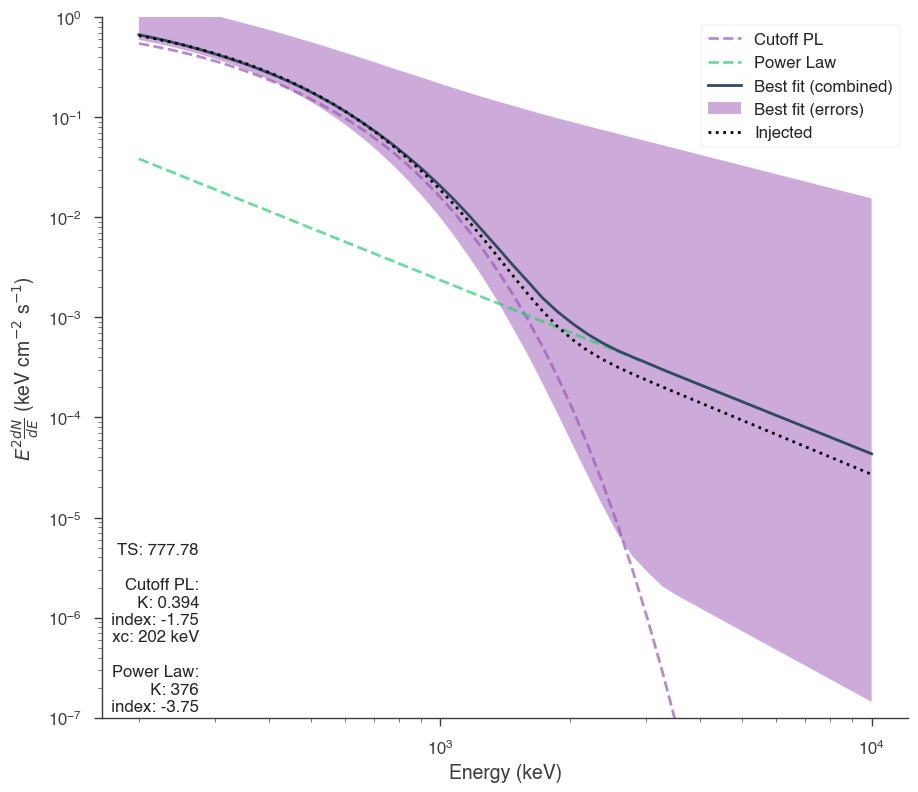

In [67]:
FONT_SIZE = 12

fig, ax = plt.subplots()

# Plot individual components
ax.plot(energy, energy*energy*flux_median_source1, label = "Cutoff PL", ls='--', alpha=0.7)
ax.plot(energy, energy*energy*flux_median_source2, label = "Power Law", ls='--', alpha=0.7)

# Plot combined
ax.plot(energy, energy*energy*flux_median, label = "Best fit (combined)", linewidth=2)
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")
ax.set_ylim(1e-7, 1)

ax.text(
    0.12, 0.25,
    f'TS: {TS:.2f}\n'
    f'\n'
    f'Cutoff PL:\n'
    f'  K: {source1.spectrum.main.Cutoff_powerlaw.K.value:.3g}\n'
    f'  index: {source1.spectrum.main.Cutoff_powerlaw.index.value:.3g}\n'
    f'  xc: {source1.spectrum.main.Cutoff_powerlaw.xc.value:.3g} keV\n'
    f'\n'
    f'Power Law:\n'
    f'  K: {source2.spectrum.main.Powerlaw.K.value:.3g}\n'
    f'  index: {source2.spectrum.main.Powerlaw.index.value:.3g}',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(fontsize = FONT_SIZE)

In [160]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source3"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source3"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source3"])

energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source3']

Best fit values:

,result,unit
parameter,,
source3.spectrum.main.Broken_powerlaw.K,9 -4 +6,1 / (keV s cm2)
source3.spectrum.main.Broken_powerlaw.xb,(3.2 -1.0 +1.5) x 10^2,keV
source3.spectrum.main.Broken_powerlaw.alpha,-2.73 +/- 0.11,
source3.spectrum.main.Broken_powerlaw.beta,-4.3 +/- 1.2,
background_cosi,1.00000 +/- 0.00020,


Correlation matrix:

1.00,0.87,-0.99,0.87,-0.72
0.87,1.00,-0.90,0.93,-0.79
-0.99,-0.90,1.00,-0.91,0.73
0.87,0.93,-0.91,1.00,-0.81
-0.72,-0.79,0.73,-0.81,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.266921e+08
total,-2.266921e+08


Values of statistical measures:

,statistical measures
AIC,-4.533842e+08
BIC,-4.533842e+08


None
  * source3 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Broken_powerlaw:
          * K:
            * value: 9.210559291998532
            * desc: Normalization (differential flux at x_b)
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * xb:
            * value: 316.03178926296283
            * desc: Break point
            * min_value: 100.0
            * max_value: 10000.0
            * unit: keV
            * is_normalization: false
          * alpha:
            * value: -2.7344718739663

Plot the fitted and injected spectra

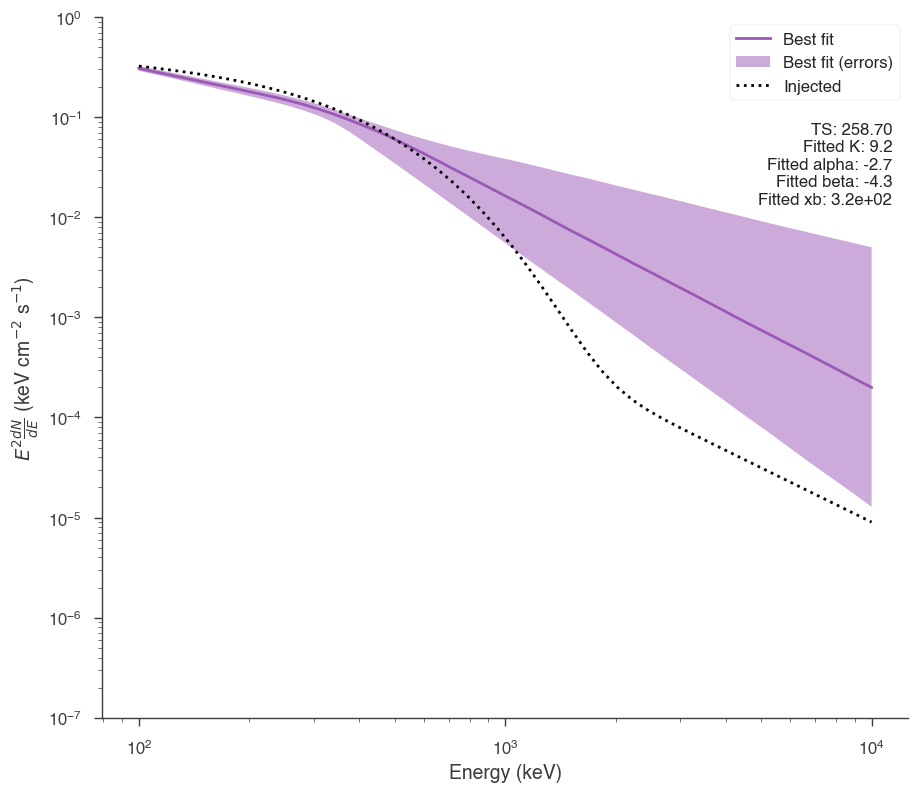

In [161]:
FONT_SIZE = 12

fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.set_ylim(1e-7, 1)

ax.text(
    0.98, 0.85,
    f'TS: {TS:.2f}\n'
    f'Fitted K: {source3.spectrum.main.Broken_powerlaw.K.value:.2g}\n'
    f'Fitted alpha: {source3.spectrum.main.Broken_powerlaw.alpha.value:.2g}\n'
    f'Fitted beta: {source3.spectrum.main.Broken_powerlaw.beta.value:.2g}\n'
    f'Fitted xb: {source3.spectrum.main.Broken_powerlaw.xb.value:.2g}',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(fontsize = FONT_SIZE)

# NGC 4151 with 1000 keV cutoff.

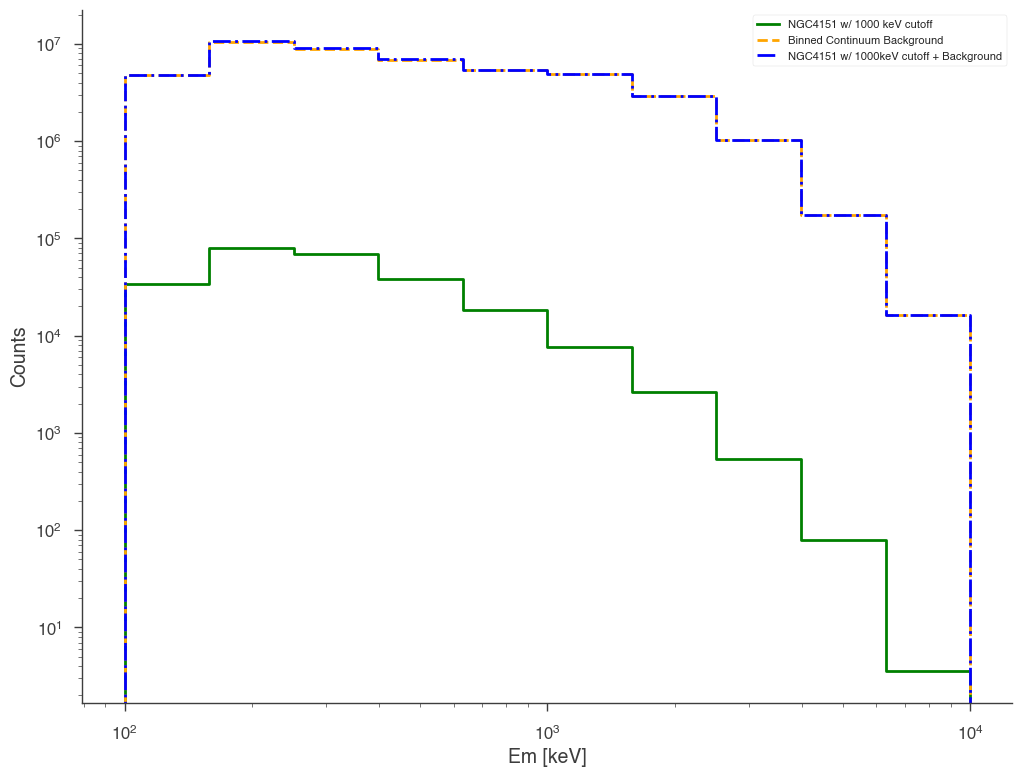

In [162]:
multiplier = 1
NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec1000_DC3_COSI_cpl_pl.hdf5")*multiplier
bkg = Histogram.open(data_path /  "AGN_Data/GammaRay/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut_NGC4151_TimeCut.hdf5")*multiplier
NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/DC3/NGC_4151_ec1000_DC3_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec1000.project("Em").draw(ax, label="NGC4151 w/ 1000 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC4151 w/ 1000keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
plt.legend()

In [163]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

In [164]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# Harsher Parameters
spectrum.K.min_value = 1e-4
spectrum.K.max_value = 1
spectrum.xc.min_value = 100 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.15

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [165]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

12:28:26 INFO      set the minimizer to minuit                                             ]8;id=4028;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=805552;file:///Users/parshadkp/.pyenv/versions/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.4 -0.4 +0.5) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.85 +/- 0.04,
source.spectrum.main.Cutoff_powerlaw.xc,(1.43 -0.24 +0.29) x 10^3,keV
background_cosi,(9.9999 +/- 0.0021) x 10^-1,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.277835e+08
total,-2.277835e+08


Values of statistical measures:

,statistical measures
AIC,-4.555670e+08
BIC,-4.555670e+08


(                                                  value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K         0.240987       -0.044284   
 source.spectrum.main.Cutoff_powerlaw.index    -1.854421       -0.040607   
 source.spectrum.main.Cutoff_powerlaw.xc     1430.921181     -244.012998   
 background_cosi                                0.999988       -0.000204   
 
                                             positive_error       error  \
 source.spectrum.main.Cutoff_powerlaw.K            0.054471    0.049378   
 source.spectrum.main.Cutoff_powerlaw.index        0.041113    0.040860   
 source.spectrum.main.Cutoff_powerlaw.xc         284.824709  264.418854   
 background_cosi                                   0.000207    0.000206   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.index                   
 source.spectrum.main.Cutoff_powerlaw.xc            

In [169]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

In [170]:
K_inj = (spectrum_inj_ec1000.evaluate_at(3000)) / u.cm / u.cm / u.s / u.keV
piv_inj = 3000. * u.keV
index_inj = -2.1

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj = spectrum_inj_ec1000_PL + spectrum_inj_ec1000

In [171]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(2.4 -0.4 +0.5) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.85 +/- 0.04,
source.spectrum.main.Cutoff_powerlaw.xc,(1.43 -0.24 +0.29) x 10^3,keV
background_cosi,(9.9999 +/- 0.0021) x 10^-1,


Correlation matrix:

1.00,-0.98,0.63,-0.13
-0.98,1.00,-0.73,0.10
0.63,-0.73,1.00,-0.29
-0.13,0.10,-0.29,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.277835e+08
total,-2.277835e+08


Values of statistical measures:

,statistical measures
AIC,-4.555670e+08
BIC,-4.555670e+08


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.24098705061000805
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.0001
            * max_value: 1.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.854420744608295
    

In [172]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_ec1000.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1'] + cosi._expected_counts['source2']

KeyError: 'source1'

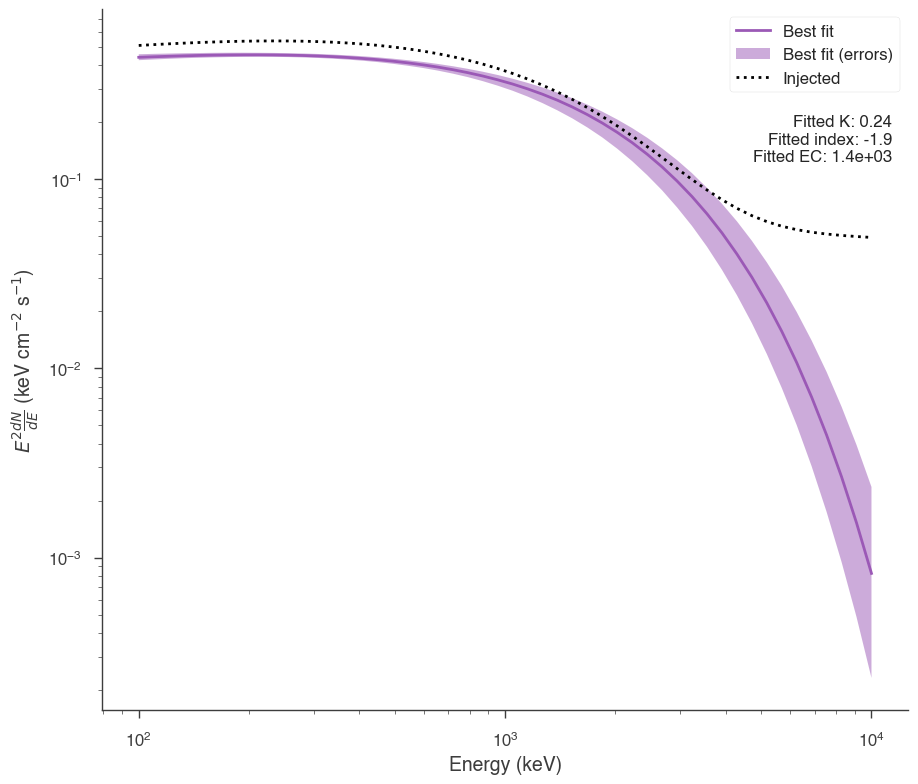

In [173]:
FONT_SIZE = 12

fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

# ax.set_ylim(1e-7, 1)

ax.text(
    0.98, 0.85,
    f'Fitted K: {source.spectrum.main.Cutoff_powerlaw.K.value:.2g}\n'
    f'Fitted index: {source.spectrum.main.Cutoff_powerlaw.index.value:.2g}\n'
    f'Fitted EC: {source.spectrum.main.Cutoff_powerlaw.xc.value:.2g}',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.legend(fontsize = FONT_SIZE)

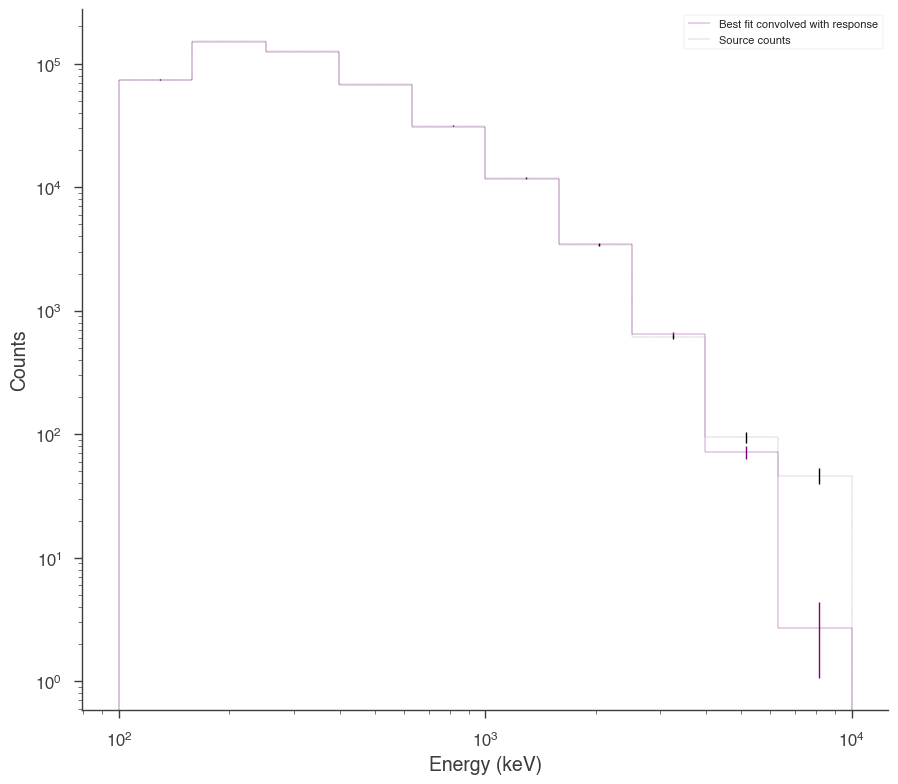

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec1000.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_ec1000.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec1000.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

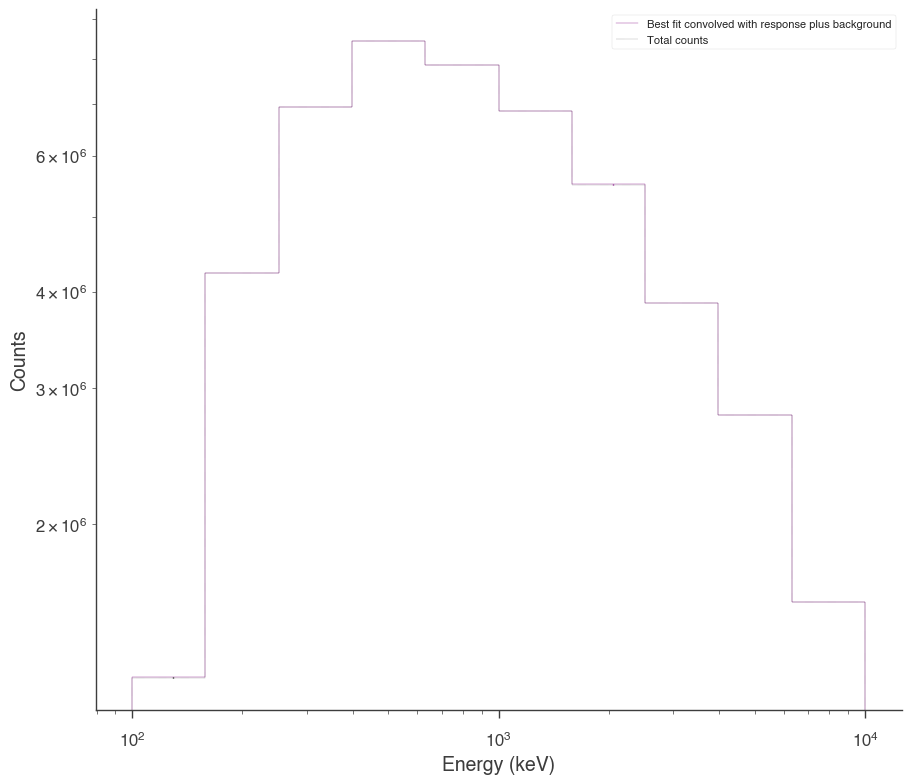

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec1000_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_ec1000_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec1000_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

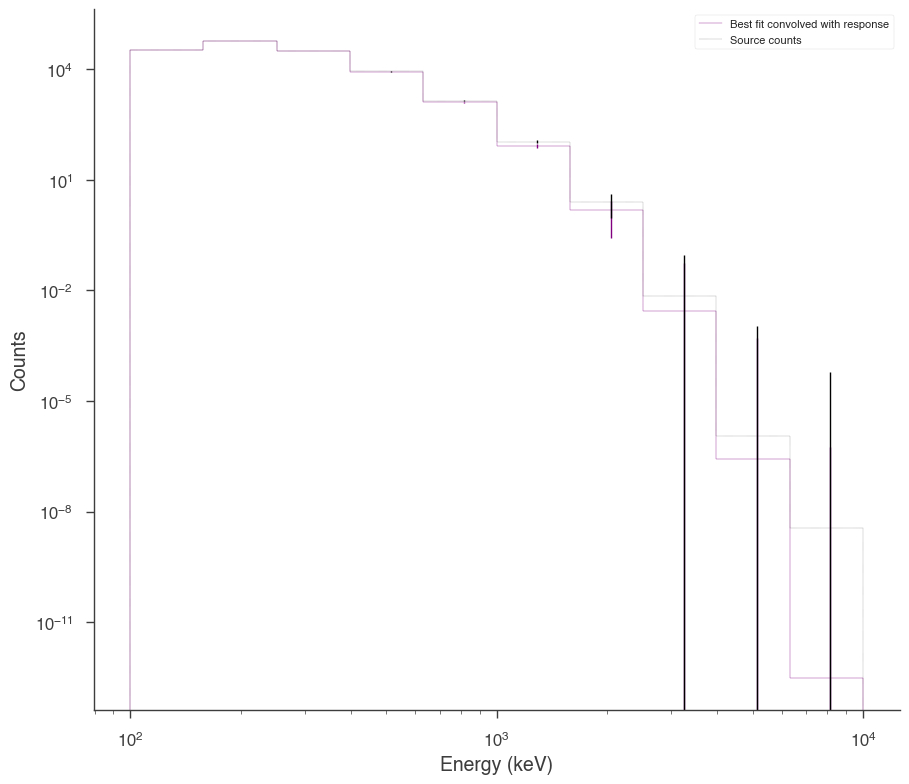

In [39]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_ec200.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

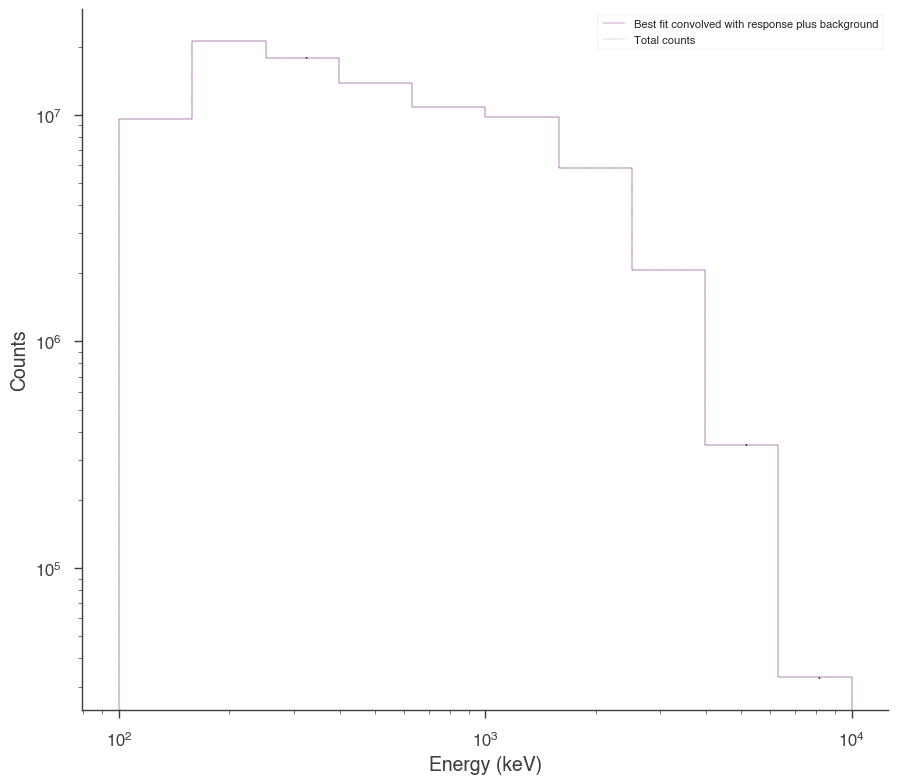

In [40]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_ec200_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()